# Mask R-CNN: детекция и сегментация повреждений кузова (CarDD)

Ноутбук решает вторую (image-) часть группового проекта №5 — детекцию и instance-сегментацию повреждений кузова автомобиля по фото для страховой компании.

**Датасет:** [CarDD](https://www.researchgate.net/publication/369458280_CarDD_A_New_Dataset_for_Vision-Based_Car_Damage_Detection) в формате COCO (`data/CarDD_release/CarDD_COCO`), 6 классов повреждений: `dent`, `scratch`, `crack`, `glass shatter`, `lamp broken`, `tire flat`. Аннотации уже содержат полигональные маски — то есть данные «из коробки» подходят под instance segmentation.

**Архитектура:** Mask R-CNN (`torchvision.models.detection.maskrcnn_resnet50_fpn_v2`), предобученная на COCO, дообучаем (fine-tune) под наши 6 классов + фон.

**Шаги работы:**
1. Загрузка датасета
2. подготовка данных для PyTorch: `Dataset`/`DataLoader`
3. Загрузка предобученного Mask R-CNN и замена «голов» под наши классы
4. Подбор гиперпараметров через баесовский поиск в `wandb`


## 0. Настройка среды

In [21]:
import os
import random
import time
import copy
from pathlib import Path
from datetime import datetime
import logging


import numpy as np
import torch
import torch.utils.data
from torch.utils.data import DataLoader

import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2 as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.ops import box_convert

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import torchvision
from torchvision import tv_tensors
from torchvision.transforms import v2 as T

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)


device: cuda


In [13]:
from datetime import datetime
import logging

LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)
_log_file = LOG_DIR / f"maskrcnn_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

formatter = logging.Formatter("%(asctime)s %(levelname)s %(message)s")

log = logging.getLogger("maskrcnn")
log.setLevel(logging.INFO)
log.handlers.clear()  # убираем старые хендлеры если ячейка перезапускалась

log.addHandler(logging.StreamHandler())
log.addHandler(logging.FileHandler(_log_file, encoding="utf-8"))

for h in log.handlers:
    h.setFormatter(formatter)

log.propagate = False  # не дублировать в root logger
log.info(f"device: {device} | log: {_log_file}")

2026-06-10 14:52:24,566 INFO device: cuda | log: logs/maskrcnn_20260610_145224.log


### Конфиг и сиды

скачать .zip с данными

In [18]:
!gdown --fuzzy https://drive.google.com/file/d/1KSxPuDzh35MXCqoavWU742XLdQQVWQjd/view?usp=sharing -O /content/CarDD_COCO.zip

Downloading...
From (original): https://drive.google.com/uc?id=1KSxPuDzh35MXCqoavWU742XLdQQVWQjd
From (redirected): https://drive.google.com/uc?id=1KSxPuDzh35MXCqoavWU742XLdQQVWQjd&confirm=t&uuid=83dda332-6a7b-4283-81c0-b13b82063e21
To: /content/CarDD_COCO.zip
 39% 1.17G/3.01G [00:18<00:24, 75.5MB/s]Traceback (most recent call last):
  File "/usr/local/bin/gdown", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gdown/__main__.py", line 171, in main
    download(
  File "/usr/local/lib/python3.12/dist-packages/gdown/download.py", line 375, in download
    for chunk in res.iter_content(chunk_size=CHUNK_SIZE):
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/requests/models.py", line 820, in generate
    yield from self.raw.stream(chunk_size, decode_content=True)
  File "/usr/local/lib/python3.12/dist-packages/urllib3/response.py", line 1091, in stream
    data = self.read

распокавать .zip

In [19]:
!unzip -q /content/CarDD_COCO.zip -d /content/

replace /content/CarDD_COCO/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [20]:
import os
print(os.path.getsize("/content/CarDD_COCO") / 1e9, "GB")

4.096e-06 GB


In [14]:
data_root = Path("/content/CarDD_COCO")

In [22]:
class CFG:
    seed = 2026

    data_root = data_root
    img_size = 512  # сторона, к которой приводим изображения при обучении
    num_classes = 6 + 1  # 6 классов повреждений + фон (background = 0)

    # настройки перебора гиперпараметров
    sweep_mode      = True  # True = короткое обучение для перебора; False = полное
    freeze_backbone = True  # заморозить backbone
    freeze_rpn      = True  # заморозить RPN
    sweep_subset_size = 500  # подвыборка картинок для обучения

    # имена классов в порядке category_id (COCO id начинаются с 1)
    class_names = ["__background__", "dent", "scratch", "crack",
                   "glass_shatter", "lamp_broken", "tire_flat"]


def seed_everything(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(CFG.seed)


## 1. Подготовка данных

In [16]:
def coco_paths(split):
    """split: 'train' | 'val' | 'test' -> (папка с картинками, json с аннотациями)."""
    return (
        data_root / f"{split}2017",
        data_root / "annotations" / f"instances_{split}2017.json",
    )


class CarDDDataset(torch.utils.data.Dataset):
    """класс для torchvision detection-моделей.

    __getitem__ возвращает (image, target), где target — словарь с ключами
    boxes, labels, masks, image_id, area, iscrowd — именно такой формат
    ожидают Mask R-CNN из torchvision и COCO-evaluator.
    """

    def __init__(self, data_root, split, transforms=None):
        self.img_dir, ann_file = _coco_paths(data_root, split)
        self.coco = COCO(str(ann_file))
        self.ids = sorted(self.coco.imgs.keys())
        self.transforms = transforms

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]

        img = torchvision.io.read_image(str(self.img_dir / img_info["file_name"]))
        if img.shape[0] == 1:                      # на всякий случай — grayscale -> RGB
            img = img.expand(3, -1, -1)
        elif img.shape[0] == 4:                    # RGBA -> RGB
            img = img[:3]

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes, labels, masks, areas, iscrowd = [], [], [], [], []
        h, w = img_info["height"], img_info["width"]
        for ann in anns:
            x, y, bw, bh = ann["bbox"]
            if bw <= 0 or bh <= 0:
                continue
            boxes.append([x, y, x + bw, y + bh])    # COCO xywh -> xyxy
            labels.append(ann["category_id"])       # уже 1..6, 0 — фон
            masks.append(self.coco.annToMask(ann))  # полигон/RLE -> бинарная маска H x W
            areas.append(ann["area"])
            iscrowd.append(ann.get("iscrowd", 0))

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            masks_t = torch.as_tensor(np.stack(masks), dtype=torch.uint8)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            masks_t = torch.zeros((0, h, w), dtype=torch.uint8)

        # таргетные признаки объекта, который ищем
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes_t, format="XYXY", canvas_size=(h, w)),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "masks": tv_tensors.Mask(masks_t),
            "image_id": torch.tensor([img_id]),
            "area": torch.as_tensor(areas, dtype=torch.float32),
            "iscrowd": torch.as_tensor(iscrowd, dtype=torch.int64),
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target


def get_transforms(train):
    tfs = [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
    ]
    if train:
        tfs += [
            T.RandomHorizontalFlip(p=0.5),
            T.RandomPhotometricDistort(p=0.3),
        ]
    tfs.append(T.SanitizeBoundingBoxes())   # выкидывает «выродившиеся» боксы после аугментаций
    return T.Compose(tfs)


def collate_fn(batch):
    return tuple(zip(*batch))


`CarDD_COCO` уже разбит на `train2017` / `val2017` / `test2017`, аннотации лежат в `annotations/instances_*.json` и содержат для каждого объекта `bbox`, полигональную `segmentation` и `category_id` (1–6, см. `CFG.class_names`).

In [17]:
for split in ("train", "val", "test"):
    img_dir, ann_file = coco_paths(split)
    coco = COCO(str(ann_file))
    cats = coco.loadCats(coco.getCatIds())
    n_objs_per_class = {c["name"]: len(coco.getAnnIds(catIds=[c["id"]])) for c in cats}
    log.info(f"{split:5s}: {len(coco.imgs):4d} изображений, {len(coco.anns):5d} объектов -> {n_objs_per_class}")


2026-06-10 14:52:52,170 INFO train: 2816 изображений,  6211 объектов -> {'dent': 1806, 'scratch': 2560, 'crack': 651, 'glass shatter': 475, 'lamp broken': 494, 'tire flat': 225}


loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
loading annotations into memory...


2026-06-10 14:52:52,238 INFO val  :  810 изображений,  1744 объектов -> {'dent': 501, 'scratch': 728, 'crack': 177, 'glass shatter': 135, 'lamp broken': 141, 'tire flat': 62}
2026-06-10 14:52:52,272 INFO test :  374 изображений,   785 объектов -> {'dent': 236, 'scratch': 307, 'crack': 70, 'glass shatter': 71, 'lamp broken': 69, 'tire flat': 32}


Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


### Трансформации и аугментации

`torchvision.transforms.v2` умеет одновременно трансформировать изображение, боксы и маски (через `tv_tensors`), что критично для detection/segmentation задач — обычные `transforms` для классификации тут не подходят.

In [18]:
train_ds = CarDDDataset(CFG.data_root, "train", transforms=get_transforms(train=True))

# обрезаем выборку для более быстрого обучения
if CFG.sweep_subset_size:
    indices = random.sample(range(len(train_ds)), CFG.sweep_subset_size)
    sweep_ds = torch.utils.data.Subset(train_ds, indices)
else:
    sweep_ds = train_ds

# num_workers=2 + persistent_workers=True: параллельная подгрузка данных в
# отдельных процессах, которые не пересоздаются между эпохами (быстрее, чем
# num_workers=0, где всё читается в основном процессе последовательно).
train_loader = DataLoader(sweep_ds, batch_size=CFG.train_batch_size, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, persistent_workers=True)

log.info(f"train: {len(train_ds)}")


loading annotations into memory...


2026-06-10 14:52:56,904 INFO train: 2816, val: 810, test: 374


Done (t=0.22s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


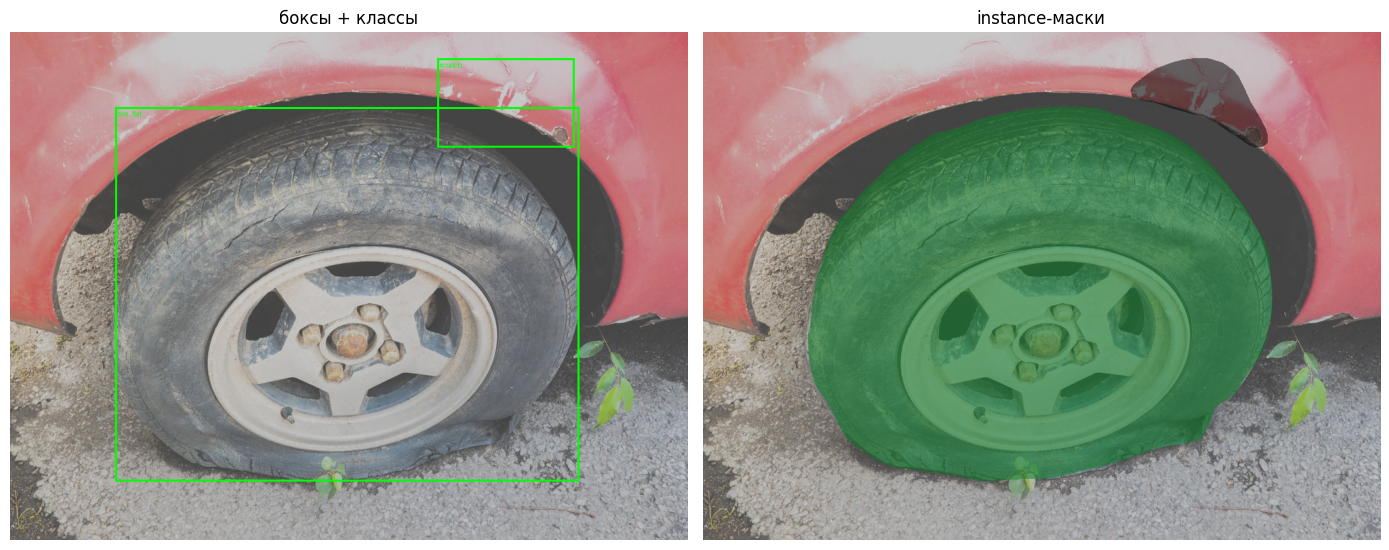

In [19]:
# проверка: разметка на одном изображении (бокс + маска + класс)
img, target = train_ds[0]
img_uint8 = (img * 255).to(torch.uint8)

labels_txt = [CFG.class_names[l] for l in target["labels"]]
img_boxes = draw_bounding_boxes(img_uint8, target["boxes"], labels=labels_txt, colors="lime", width=3)
img_masks = draw_segmentation_masks(img_uint8, target["masks"].bool(), alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_boxes.permute(1, 2, 0)); axes[0].set_title("боксы + классы"); axes[0].axis("off")
axes[1].imshow(img_masks.permute(1, 2, 0)); axes[1].set_title("instance-маски");  axes[1].axis("off")
plt.tight_layout(); plt.show()


## 3. Модель: Mask R-CNN с предобученным бэкбоном

Берём `maskrcnn_resnet50_fpn_v2`, предобученную на COCO (80 классов), и заменяем две «головы»:

- `box_predictor` (классификация + регрессия боксов) — под `CFG.num_classes`;
- `mask_predictor` (попиксельная сегментация маски внутри бокса) — тоже под `CFG.num_classes`.

Большую часть данных оставляем замороженными для экономии времени работы (`backbone` и `RPN`)

In [11]:
def get_model(num_classes, pretrained=True):
    weights = "DEFAULT" if pretrained else None
    model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
        weights=weights, min_size=CFG.img_size, max_size=int(CFG.img_size * 1.5)
    )

    # box head: in_features зависит от бэкбона, поэтому берём его из текущего слоя
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # mask head
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model


model = get_model(CFG.num_classes, pretrained=True).to(device)
log.info(model.roi_heads.box_predictor)
log.info(model.roi_heads.mask_predictor)


In [12]:
# заморозка слоёв для быстрого перебора гиперпараметров
if CFG.freeze_backbone:
    for p in model.backbone.parameters():
        p.requires_grad = False

if CFG.freeze_rpn:
    for p in model.rpn.parameters():
        p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
log.info(f"Обучаемых параметров: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)")


## 4. Дообучение с перебором параметров

Mask R-CNN в режиме `train()` сам считает и возвращает словарь лоссов (`loss_classifier`, `loss_box_reg`, `loss_mask`, `loss_objectness`, `loss_rpn_box_reg`)

In [20]:
def train_one_epoch(model, optimizer, loader, device, epoch, log_every=50):
    model.train()
    running = {}
    t0 = time.time()

    for i, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        for k, v in loss_dict.items():
            running[k] = running.get(k, 0.0) + v.item()
        running["loss_total"] = running.get("loss_total", 0.0) + loss.item()

        if (i + 1) % log_every == 0:
            avg = {k: v / (i + 1) for k, v in running.items()}
            log.info(f"[epoch {epoch}] step {i+1}/{len(loader)} | " +
                     " | ".join(f"{k}={v:.4f}" for k, v in avg.items()))
            global_step = (epoch - 1) * len(loader) + (i + 1)
            wandb.log({f"step/{k}": v for k, v in avg.items()},
                      step=global_step)

    n = len(loader)
    epoch_metrics = {k: v / n for k, v in running.items()}
    epoch_metrics["epoch_time_sec"] = time.time() - t0
    return epoch_metrics


@torch.no_grad()
def evaluate_loss(model, loader, device):
    """Mask R-CNN не отдаёт лоссы в eval()-режиме, поэтому временно переключаем
    в train() — но БЕЗ backward/optimizer.step — чтобы получить val-лоссы для логов."""
    was_training = model.training
    model.train()
    running = {}

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        for k, v in loss_dict.items():
            running[k] = running.get(k, 0.0) + v.item()
        running["loss_total"] = running.get("loss_total", 0.0) + loss.item()

    model.train(was_training)
    n = len(loader)
    return {f"val_{k}": v / n for k, v in running.items()}


### Логирование в W&B

In [23]:
import wandb

ENTITY = "maty11-hse"
PROJECT = "test_mask_r_cnn"
# wandb.login()  # раскомментировать при первом запуске в новой среде
run = wandb.init(
    entity=ENTITY,
    project=PROJECT,
    group="car_damage_recognition",
    name="maskrcnn_resnet50_fpn_v2_hparam_tune",
    config={
        "model_type": "maskrcnn_resnet50_fpn_frozen",
        "dataset": "CarDD_COCO",
        "num_classes": CFG.num_classes,
        "epochs": CFG.num_epochs,
        "batch_size": CFG.train_batch_size,
        "lr": CFG.lr,
        "optimizer": "SGD",
    },
)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: maty11 (maty11-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [24]:
# функция одного эксперимента с фиксированными весами
# method="bayes" — байесовская оптимизация: каждый следующий запуск выбирается
# подбор параметров на основе уже полученных результатов.
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_loss_total", "goal": "minimize"},
    "parameters": {
        "lr":               {"values": [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02]},
        "momentum":         {"values": [0.85, 0.9, 0.95, 0.99]},
        "weight_decay":     {"values": [0.00001, 0.0001, 0.0005, 0.001, 0.005]},
        "lr_step_size":     {"values": [2, 3, 5, 7]},
        "lr_gamma":         {"values": [0.1, 0.3, 0.5, 0.7]},
        "train_batch_size": {"values": [2, 4, 8]},
    },
}


def run_trial(config=None):
    """Один эксперимент свипа: создаём модель, замораживаем слои,
    обучаем CFG.num_epochs эпох (2), логируем val_loss в W&B —
    агент сам подбирает следующие параметры."""
    with wandb.init(config=config, group="hparam_sweep") as run:
        cfg = wandb.config

        # свежая модель для каждого эксперимента
        m = get_model(CFG.num_classes, pretrained=True).to(device)

        if CFG.freeze_backbone:
            for p in m.backbone.parameters():
                p.requires_grad = False
        if CFG.freeze_rpn:
            for p in m.rpn.parameters():
                p.requires_grad = False

        params = [p for p in m.parameters() if p.requires_grad]
        opt = torch.optim.SGD(
            params, lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay
        )
        sched = torch.optim.lr_scheduler.StepLR(
            opt, step_size=cfg.lr_step_size, gamma=cfg.lr_gamma
        )

        # пересоздаём train_loader с batch_size из свипа
        trial_loader = DataLoader(
            train_ds, batch_size=cfg.train_batch_size, shuffle=True,
            collate_fn=collate_fn, num_workers=2, persistent_workers=True,
        )

        for epoch in range(1, CFG.num_epochs + 1):
            train_metrics = train_one_epoch(m, opt, trial_loader, device, epoch)
            val_metrics   = evaluate_loss(m, val_loader, device)
            sched.step()
            run.log({
                "epoch": epoch,
                "lr": opt.param_groups[0]["lr"],
                **train_metrics,
                **val_metrics,
            })


In [ ]:
# всего 15 запусков, каждый раз - новые параметры
sweep_id = wandb.sweep(sweep_config, entity=ENTITY, project=PROJECT)
wandb.agent(sweep_id, run_trial, count=15)


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f7e3fdae9c0>> (for pre_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Create sweep with ID: 3xjur8u6
Sweep URL: https://wandb.ai/maty11-hse/test_mask_r_cnn/sweeps/3xjur8u6


wandb: Agent Starting Run: ec9g0ua6 with config:
wandb: 	lr: 0.001
wandb: 	lr_gamma: 0.7
wandb: 	lr_step_size: 5
wandb: 	momentum: 0.99
wandb: 	train_batch_size: 8
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


2026-06-10 15:03:10,086 INFO [epoch 1] step 50/352 | loss_classifier=0.5715 | loss_box_reg=0.1636 | loss_mask=0.7002 | loss_objectness=0.2245 | loss_rpn_box_reg=0.0249 | loss_total=1.6847
2026-06-10 15:04:15,698 INFO [epoch 1] step 100/352 | loss_classifier=0.4081 | loss_box_reg=0.1613 | loss_mask=0.5875 | loss_objectness=0.2107 | loss_rpn_box_reg=0.0232 | loss_total=1.3909
2026-06-10 15:05:21,657 INFO [epoch 1] step 150/352 | loss_classifier=0.3401 | loss_box_reg=0.1587 | loss_mask=0.5390 | loss_objectness=0.2158 | loss_rpn_box_reg=0.0236 | loss_total=1.2772
2026-06-10 15:06:27,163 INFO [epoch 1] step 200/352 | loss_classifier=0.3012 | loss_box_reg=0.1575 | loss_mask=0.5038 | loss_objectness=0.2024 | loss_rpn_box_reg=0.0221 | loss_total=1.1869
2026-06-10 15:07:33,433 INFO [epoch 1] step 250/352 | loss_classifier=0.2773 | loss_box_reg=0.1565 | loss_mask=0.4795 | loss_objectness=0.2017 | loss_rpn_box_reg=0.0220 | loss_total=1.1371
2026-06-10 15:08:41,095 INFO [epoch 1] step 300/352 | lo

...

wandb: Agent Starting Run: 9n95ixid with config:
wandb: 	lr: 0.01
wandb: 	lr_gamma: 0.7
wandb: 	lr_step_size: 7
wandb: 	momentum: 0.95
wandb: 	train_batch_size: 4
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


2026-06-10 16:55:07,505 INFO [epoch 1] step 50/704 | loss_classifier=0.3211 | loss_box_reg=0.1625 | loss_mask=0.5930 | loss_objectness=0.1924 | loss_rpn_box_reg=0.0194 | loss_total=1.2884
2026-06-10 16:55:39,956 INFO [epoch 1] step 100/704 | loss_classifier=0.2559 | loss_box_reg=0.1619 | loss_mask=0.5322 | loss_objectness=0.1960 | loss_rpn_box_reg=0.0205 | loss_total=1.1664
2026-06-10 16:56:10,491 INFO [epoch 1] step 150/704 | loss_classifier=0.2269 | loss_box_reg=0.1516 | loss_mask=0.5002 | loss_objectness=0.1872 | loss_rpn_box_reg=0.0208 | loss_total=1.0866
2026-06-10 16:56:41,865 INFO [epoch 1] step 200/704 | loss_classifier=0.2103 | loss_box_reg=0.1459 | loss_mask=0.4755 | loss_objectness=0.1791 | loss_rpn_box_reg=0.0202 | loss_total=1.0311
2026-06-10 16:57:13,856 INFO [epoch 1] step 250/704 | loss_classifier=0.2018 | loss_box_reg=0.1429 | loss_mask=0.4611 | loss_objectness=0.1837 | loss_rpn_box_reg=0.0206 | loss_total=1.0100
2026-06-10 16:57:44,809 INFO [epoch 1] step 300/704 | lo

epoch,▁█
epoch_time_sec,▁█
loss_box_reg,█▁
loss_classifier,█▁
loss_mask,█▁
loss_objectness,█▁
loss_rpn_box_reg,█▁
loss_total,█▁
lr,▁▁
step/loss_box_reg,██▇▆▆▅▅▅▅▄▄▄▄▄▁▁▁▁▁▁▂▂▂▂▁▁▁▁
+11,...


wandb: Agent Starting Run: qpcz98f8 with config:
wandb: 	lr: 0.02
wandb: 	lr_gamma: 0.7
wandb: 	lr_step_size: 7
wandb: 	momentum: 0.99
wandb: 	train_batch_size: 2
wandb: 	weight_decay: 1e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


2026-06-10 17:12:46,876 INFO [epoch 1] step 50/1408 | loss_classifier=0.2939 | loss_box_reg=0.1474 | loss_mask=0.7835 | loss_objectness=0.1859 | loss_rpn_box_reg=0.0184 | loss_total=1.4291
2026-06-10 17:13:02,444 INFO [epoch 1] step 100/1408 | loss_classifier=0.2472 | loss_box_reg=0.1505 | loss_mask=0.6977 | loss_objectness=0.1965 | loss_rpn_box_reg=0.0196 | loss_total=1.3114
2026-06-10 17:13:18,007 INFO [epoch 1] step 150/1408 | loss_classifier=0.2292 | loss_box_reg=0.1512 | loss_mask=0.6432 | loss_objectness=0.1831 | loss_rpn_box_reg=0.0186 | loss_total=1.2253
2026-06-10 17:13:32,685 INFO [epoch 1] step 200/1408 | loss_classifier=0.2164 | loss_box_reg=0.1476 | loss_mask=0.6055 | loss_objectness=0.1858 | loss_rpn_box_reg=0.0193 | loss_total=1.1746
2026-06-10 17:13:47,350 INFO [epoch 1] step 250/1408 | loss_classifier=0.2096 | loss_box_reg=0.1466 | loss_mask=0.5940 | loss_objectness=0.1936 | loss_rpn_box_reg=0.0205 | loss_total=1.1643
2026-06-10 17:14:01,856 INFO [epoch 1] step 300/140